# Neural transport and learning dynamics from data

*Introduction to Control and Machine Learning · Part IV: Fusion · Notebook 16*

> **Central question.** *How does a neural ODE move a probability distribution, how do we measure how well it does so, and can the same fields learn an unknown dynamics from trajectories?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 80–100 min · DEEPER LOOK and RESEARCH WINDOW ≈ 20 min more |
| **Execution time** | about ten seconds |
| **Exercises** | 6 exercises, ≈ 100–140 min |
| **Prerequisites** | [notebook 14](14_classification_as_simultaneous_control.ipynb) (exact ReLU actions, shear constructions), [notebook 06](06_variational_principles_gradient_flows.ipynb) (discrete optimal transport, §10, and the example E8), [notebook 13](13_resnets_neural_odes.ipynb) (neural ODEs), [notebook 09](09_machine_learning_foundations_generalization.ipynb) (the protocol) |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 151, 372–383 (see the Source map at the end) |
| **Notation** | `notation.md` §7. Densities and measures $\rho$, $\rho_0$, $\rho_T$; velocity field $V(x,t)$; Wasserstein-1 distance $W_1$; $\mathcal P^{ac}_c(\mathbb R^d)$ the compactly supported, absolutely continuous probability measures. The width is $P$ (the slides' $p$), and $L$ counts switches, as on p. 373 |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–6 (push-forward and the transport equation; measuring with $W_1$; atoms to atoms; laws are not atoms; learning a dynamics with semi-autonomous neural ODEs), Figures 1–4, Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §8 (the Gronwall estimate, checked; $C/P$ versus $C/\sqrt P$), Exercises 3–4.
> *Research-oriented:* the RESEARCH WINDOW §9 and the `ADVANCED` Exercises 5–6.

**Learning objectives.** After this notebook you should be able to

1. describe the transport of a measure by a flow (push-forward, weak identity, transport equation), and explain why atoms keep their masses while densities change by a volume factor;
2. compute $W_1$ in one dimension through quantiles, and between equal-size samples through an optimal assignment with Euclidean cost;
3. construct a ReLU control that sends finitely many atoms exactly to finitely many targets, and explain why this does not transport the underlying law;
4. state the neural transport theorem of p. 373 with its hypotheses, and audit its switch count;
5. fit a semi-autonomous neural ODE to trajectory data with a validation choice and a single pre-declared final evaluation, and relate field errors to trajectory errors.

## Where are we?
`CORE`

> **Recap.** [Notebook 14](14_classification_as_simultaneous_control.ipynb): one ReLU neuron with constant control freezes a half-space and moves the other exactly; shears move points along one direction without changing their "heights". [Notebook 06](06_variational_principles_gradient_flows.ipynb), §10: Monge's problem (p. 151) between two samples of E8 is a linear program whose optimal plans are permutations.

Notebooks 13–15 followed points. When the points are many, samples of a distribution, it is natural to follow the **distribution** itself. A neural ODE then transports a probability measure, as generative "normalizing flows" do. The slides call this **neural transport** (pp. 372–374). The last part of the slides uses the same fields for a different purpose, **learning an unknown dynamics from trajectories** (pp. 375–383). This notebook treats both. It has two laboratories, A (transport) and B (learning), and one protocol (`reports/protocol_12_16.md`, section 16), frozen before any evaluation data were drawn.

## 1. Transporting a measure: push-forward and the transport equation
`CORE`

The neural ODE $x'=w(t)\sigma(a(t)\cdot x+b(t))$, $x(0)=x_0$, defines a flow map $\Phi_T:x_0\mapsto x(T)$. The slides read its trajectories as **the characteristics of the transport equation** (p. 372):
$$
\partial_t\rho+\operatorname{div}_x\big(V(x,t)\,\rho\big)=0,\qquad\rho(0)=\rho_0,\qquad V(x,t)=w(t)\sigma(a(t)\cdot x+b(t)),
$$
where *$V$ is Lipschitz in space*: true for the ReLU, with piecewise-constant controls. The solution is the **push-forward** $\rho(T)=\Phi_{T\#}\rho_0$: the mass that $\rho_0$ puts on a set $B$ is the mass that $\rho(T)$ puts on $\Phi_T(B)$. Equivalently, for every bounded continuous test function $\varphi$,
$$
\int\varphi\,d\rho(T)=\int\varphi\big(\Phi_T(x)\big)\,d\rho_0(x)\qquad\text{(the weak identity).}
$$
*(The weak identity is the standard definition of the push-forward; we state it without proof.)* Two cases look different but follow the same rule.

- **Atoms.** If $\rho_0=\sum_im_i\delta_{x_i}$, then $\rho(T)=\sum_im_i\delta_{\Phi_T(x_i)}$. Each atom moves along its characteristic **with its mass $m_i$**; no volume factor appears. Transporting an empirical measure means moving its points and keeping their weights.
- **Densities.** If $\rho_0$ has a density and $\Phi_T$ is a smooth bijection, the density at $\Phi_T(x)$ is $\rho_0(x)/|\det D\Phi_T(x)|$. Where the flow expands volume, the density drops. For one ReLU expansion action ($w\parallel a$, $a\cdot w>0$, §2 of notebook 14), $\det D\Phi_t=e^{(a\cdot w)t}$ on the active side and $1$ on the frozen side *(pedagogical addition)*.

**Mass is conserved in both cases**, and it is the *weights* (for atoms) or the *density times volume* (for densities) that carry it. The cell checks the weak identity for a density pushed by $\Phi(x)=2x+1$ on the line, and the bookkeeping of masses for three atoms.

> **Predict.** The uniform density on $[0,1]$ is pushed by $\Phi(x)=2x+1$. What is the new density? What happens to atoms of masses $0.5,0.3,0.2$?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from src.ml_utils import make_streams, samples_E8
from src.control_utils import harmonic_oscillator
from src.relu_control_utils import relu_action_exact
from src.transport_utils import (w1_1d, w1_assignment, two_phase_transport, transport, sa_features, fit_outer_weights,
                                 sa_node_rollout, trajectory_error)
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=4, suppress=True)

# Identifiable streams (reports/protocol_12_16.md, section 16): "data" (E8 atoms, then the initial conditions of
# Laboratory B), "features" (SA-NODE inner parameters), "dev" (exercises only), "eval" (final evaluation data, drawn
# once, after every choice is fixed).
streams, stream_keys = make_streams(16, ["data", "features", "dev", "eval"])
X0_atoms, X1_atoms = samples_E8(streams["data"], n=8)            # E8: 8 points of rho_0 = N((0.5,0.5), 0.15^2 I), 8 of U([0,1]^2)
print("stream keys:", stream_keys)

# Section 1: push-forward on the line by Phi(x) = 2x + 1.
Phi_line = lambda x: 2 * x + 1
nodes, weights = np.polynomial.legendre.leggauss(40)
x01, w01 = 0.5 * (nodes + 1), 0.5 * weights                      # quadrature on [0, 1]
x13, w13 = 2 + nodes, weights                                    # quadrature on [1, 3]
for name, phi in (("cos", np.cos), ("x^2", lambda x: x**2)):
    lhs = np.sum(w13 * 0.5 * phi(x13))                           # integral of phi against the pushed density 1/2 on [1, 3]
    rhs = np.sum(w01 * 1.0 * phi(Phi_line(x01)))                 # integral of phi(Phi(x)) against the uniform density on [0, 1]
    print(f"weak identity with phi = {name}: {lhs:.12f} = {rhs:.12f}")
atoms, masses = np.array([0.0, 0.4, 1.0]), np.array([0.5, 0.3, 0.2])
print("atoms", atoms, "-> ", Phi_line(atoms), "; masses stay", masses, "; total", masses.sum(),
      "; the density 1 on [0, 1] becomes the density 1/2 on [1, 3]")

stream keys: {'data': (16, 0), 'features': (16, 3), 'dev': (16, 6), 'eval': (16, 4)}
weak identity with phi = cos: -0.350175488374 = -0.350175488374
weak identity with phi = x^2: 4.333333333333 = 4.333333333333
atoms [0.  0.4 1. ] ->  [1.  1.8 3. ] ; masses stay [0.5 0.3 0.2] ; total 1.0 ; the density 1 on [0, 1] becomes the density 1/2 on [1, 3]


*Reading the output (answer to the prediction).* The pushed density is $\frac12$ on $[1,3]$: the interval has doubled, so the density halves, and the weak identity holds to quadrature accuracy for both test functions. The atoms move to $1$, $1.8$, $3$ and keep their masses $0.5$, $0.3$, $0.2$. In an empirical measure, no point becomes "lighter" because the flow spreads the points apart.

## 2. Measuring transport: the Wasserstein-1 distance
`CORE`

The neural transport theorem measures success with the **Wasserstein-1 distance** (p. 373),
$$
W_1(\mu,\nu)=\min_{\pi}\int|x-y|\,d\pi(x,y),
$$
the cheapest total distance travelled when moving $\mu$ onto $\nu$, minimized over transport plans $\pi$ with marginals $\mu$ and $\nu$. This is the **Kantorovich** formulation, over plans, of **Monge's** problem (p. 151), which looks instead for a map $T$ pushing $\mu$ onto $\nu$; a plan may split the mass of a point, a map may not. *(The two computational facts below are standard; we use them without proof.)*

- **On the line**, $W_1(\mu,\nu)=\int_{\mathbb R}|F_\mu-F_\nu|\,dx=\int_0^1|F_\mu^{-1}(s)-F_\nu^{-1}(s)|\,ds$, with $F$ the cumulative distribution functions. For two samples of equal size $n$ and weights $1/n$, it is the mean distance between the sorted samples: **matching by quantiles is optimal**.
- **Between two samples of equal size $n$ with weights $1/n$ in $\mathbb R^d$**, the plans form the polytope of doubly stochastic matrices divided by $n$, whose extreme points are the permutation matrices divided by $n$ (Birkhoff–von Neumann, notebook 06). A linear cost attains its minimum at an extreme point, so an optimal plan can be taken to be a permutation, a Monge map, and $W_1=\min_s\frac1n\sum_i|x_i-y_{s(i)}|$: an **assignment problem with Euclidean cost**. The optimal mean *squared* cost, used in notebook 06, is $W_2^2$, and $W_2$ is its square root; the theorem of p. 373 uses $W_1$, and we do not replace it by a sliced or squared surrogate.

Both are computed by `w1_1d` and `w1_assignment`. The cell checks them on cases that can be done by hand.

In [2]:
print("W1(delta_0, delta_1) =", w1_1d([0.0], [1.0]))
print("W1((delta_0 + delta_1)/2, delta_1/2) =", w1_1d([0.0, 1.0], [0.5]))
print("W1(0.25 delta_0 + 0.75 delta_1, delta_1) =", w1_1d([0.0, 1.0], [1.0], wx=[0.25, 0.75]), " (weights are masses)")
x_s, y_s = np.array([0.3, -1.0, 2.0, 0.7]), np.array([1.5, 0.0, -0.2, 0.4])
print(f"four points each: by CDFs {w1_1d(x_s, y_s):.6f}, by sorted pairs {np.mean(np.abs(np.sort(x_s) - np.sort(y_s))):.6f}, "
      f"by assignment {w1_assignment(x_s[:, None], y_s[:, None])[0]:.6f}")
W1_atoms_before, match = w1_assignment(X0_atoms, X1_atoms)
print(f"E8 atoms: W1 = {W1_atoms_before:.4f}, optimal assignment {match}")

W1(delta_0, delta_1) = 1.0
W1((delta_0 + delta_1)/2, delta_1/2) = 0.5
W1(0.25 delta_0 + 0.75 delta_1, delta_1) = 0.25  (weights are masses)
four points each: by CDFs 0.475000, by sorted pairs 0.475000, by assignment 0.475000
E8 atoms: W1 = 0.2715, optimal assignment [4 7 6 5 3 0 1 2]


## 3. Atoms to atoms, exactly
`CORE`

*"Atomic initial data can be driven to atomic final targets"* (p. 372). In the plane, the shear construction of notebook 14 does it in two phases. This is our construction *(pedagogical addition)*; it follows the two steps that the slides describe for simultaneous control (p. 355: *control $d-1$ coordinates, then the remaining coordinate*).

1. **Phase 1:** shears along $e_1$, with heights $x^{(2)}$, set every first coordinate to its target; second coordinates do not change.
2. **Phase 2:** shears along $e_2$, with heights $x^{(1)}$ (now the target first coordinates), set every second coordinate to its target; first coordinates do not change.

Each phase is the triangular construction of notebook 14, so each atom lands **exactly** on its target, given distinct initial second coordinates and distinct target first coordinates. Which atom goes to which target is a free choice. We take the **optimal assignment** for $W_1$ computed above: *theory of optimal transport → neural transport* (p. 372). The control is **transport (i)** of Laboratory A.

> **Predict.** After transport (i), what is $W_1$ between the transported atoms and the target atoms? How large must the controls be?

layers 16 (switches 15); largest speed 7.41e+03
max |transported atom - target| = 7.4e-13;  W1(transported atoms, target atoms) = 1.5e-13


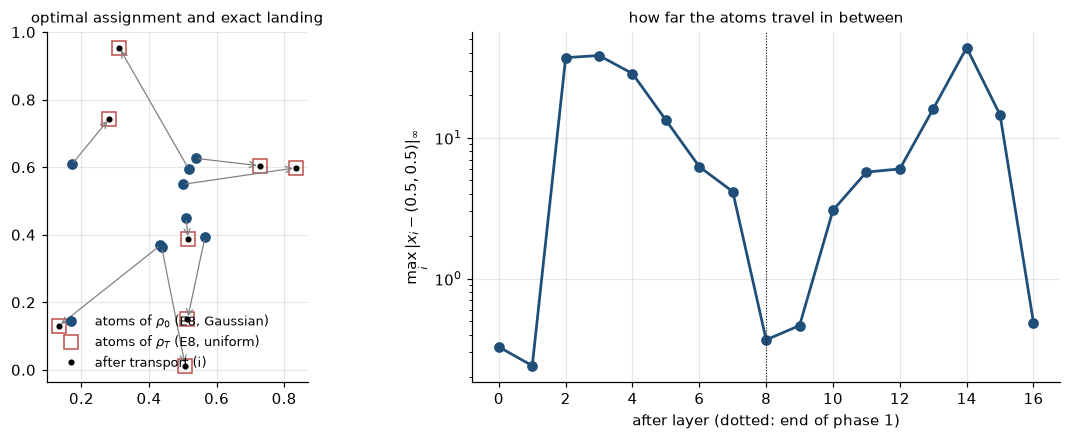

In [3]:
targets = X1_atoms[match]                                        # the optimal assignment for W1
layers_i = two_phase_transport(X0_atoms, targets, T=1.0)         # transport (i): 16 shear layers, width 1
path_atoms = [X0_atoms]
for layer in layers_i:
    path_atoms.append(transport(path_atoms[-1], [layer]))
atoms_after_i = path_atoms[-1]
print(f"layers {len(layers_i)} (switches {len(layers_i) - 1}); largest speed {max(np.abs(L[4]).max() for L in layers_i):.2e}")
print(f"max |transported atom - target| = {np.abs(atoms_after_i - targets).max():.1e};  "
      f"W1(transported atoms, target atoms) = {w1_assignment(atoms_after_i, X1_atoms)[0]:.1e}")

path = np.array(path_atoms)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.1))
for i in range(len(X0_atoms)):
    ax1.annotate("", xy=targets[i], xytext=X0_atoms[i], arrowprops=dict(arrowstyle="->", color=COLORS["reference"], lw=0.8))
ax1.plot(*X0_atoms.T, "o", color=COLORS["state"], label=r"atoms of $\rho_0$ (E8, Gaussian)")
ax1.plot(*X1_atoms.T, "s", mfc="none", ms=9, color=COLORS["control"], label=r"atoms of $\rho_T$ (E8, uniform)")
ax1.plot(*atoms_after_i.T, ".", color="black", label="after transport (i)")
ax1.set_aspect("equal"); ax1.legend(fontsize=8.5, loc="lower left"); ax1.set_title("optimal assignment and exact landing", fontsize=10)
ax2.semilogy(np.arange(len(path)), np.abs(path - 0.5).max(axis=(1, 2)), "o-", color=COLORS["state"])
ax2.axvline(len(layers_i) / 2, color="black", lw=0.7, ls=":")
ax2.set_xlabel("after layer (dotted: end of phase 1)"); ax2.set_ylabel(r"$\max_i|x_i-(0.5,0.5)|_\infty$")
ax2.set_title("how far the atoms travel in between", fontsize=10)
plt.tight_layout(); plt.show()

**Figure 1.** Transport (i) of the eight E8 atoms. *Left:* the atoms of $\rho_0$ (circles), of $\rho_T$ (squares), the optimal $W_1$ assignment (arrows) and the positions after the 16 shear layers (black dots). *Right:* the largest distance of an atom from the centre of the square after each layer, on a logarithmic scale.

*Interpretation (answer to the prediction).* Every atom lands on its target to rounding (printed), so $W_1$ between the transported and target atoms is $0$ up to rounding. The control is not small: the printed speeds reach thousands, and the atoms make large excursions between the layers (right) before the last layers bring them back. Atoms can indeed be driven to atoms; the question of §4 is what this does to the distribution the atoms were drawn from.

## 4. Laws are not atoms
`CORE`

> **Theorem (Álvarez-López–Slimane–Zuazua; p. 373), transcribed without its switch formula.** *Let $d\ge1$, $\rho_0\in\mathcal P^{ac}_c(\mathbb R^d)$ and $\rho_T=U([0,1]^d)$. For any $T>0$ and $\varepsilon>0$, and width $p\ge1$, there is a piecewise-constant control $(w,a,b)\in L^\infty\big((0,T);\mathbb R^{d\times p}\times\mathbb R^{p\times d}\times\mathbb R^p\big)$ such that the neural transport solution satisfies $W_1(\rho(T),\rho_T)<\varepsilon$, with a finite number $L$ of switches depending on $d$, $p$ and $\varepsilon$.* The proof sketched in the slides: compress $\rho_0$ into $[0,1]^d$; partition the cube into rectangles $C_{i,j}$ and $G_{i,j}$ carrying the same small masses under $\rho_0$ and $\rho_T$; transform each $C_{i,j}$ into $G_{i,j}$ by compressions and expansions (pp. 373–374).

**Audit of the switch count.** The slides print $L=\lceil2d/p\rceil+\big\lceil\frac{1}{p-d+1}\big(\frac{3^{1+d}\sqrt d}{\varepsilon}\big)^d\big\rceil-1$, under the assumptions $q\in[1,\frac d{d-1})$ and $p\ge1$. As printed it cannot be checked:
- the factor $\frac1{p-d+1}$ is undefined for $p=d-1$ and negative for $p<d-1$, although $p\ge1$ is allowed;
- the parameter $q$ appears in the hypotheses but nowhere in the conclusion;
- the interval $[1,\frac d{d-1})$ is undefined for $d=1$.
We therefore **do not reproduce the formula**. What survives is qualitative: finitely many switches, growing as $\varepsilon\to0$, with the factor $\varepsilon^{-d}$ inside the printed expression suggesting a curse of dimension.

**Hypotheses that matter here.** The theorem concerns an **absolutely continuous, compactly supported** initial law, approximated in $W_1$. The atoms of §3 are a different object, and exact landing of eight atoms says nothing about a law. Also, the Gaussian $\rho_0$ of E8 is **not compactly supported**, so the theorem does not apply to it as stated, although more than $99.8\%$ of its mass (about $99.83\%$) lies in the unit square.

**Laboratory A: two transports, judged on new samples.** Both are fixed in the protocol before any evaluation sample was drawn. Every particle is moved by the same declared field, applied exactly.

- **Transport (i):** the exact atomic matching of §3.
- **Transport (ii): compress/expand at the level of the law** *(pedagogical addition)*.
  - Four **expansions** about the centre $(0.5,0.5)$. In each half-plane $\{x^{(1)}>0.5\}$, $\{x^{(1)}<0.5\}$, $\{x^{(2)}>0.5\}$, $\{x^{(2)}<0.5\}$ an action with $w\parallel a$ and $a\cdot w=\ln2$ acts for unit time, multiplying distances from the centre lines by $2$. The factor is the ratio of standard deviations, $(1/\sqrt{12})/0.15\approx1.9$, rounded.
  - Four **contractions** towards the sides of the unit square ($a\cdot w=-3$), which pull outlying points towards the square without letting them cross.
  - These are the parallel/contraction/expansion actions of notebook 14, the building blocks of the slides' proof, used here without any attempt at the full construction.
- **Evaluation:** 400 new points of $\rho_0$ and 400 of $\rho_T$, from the reserved stream, drawn after both transports were fixed. We report $W_1$ before and after each transport, for the atoms and for the new samples.

> **Predict.** Which transport will bring the new sample of $\rho_0$ closer to the new sample of $\rho_T$?

                          W1 atoms (n = 8)    W1 new samples (n = 400)
before                            2.71e-01                    0.1999
(i) atomic matching               1.52e-13                   72.0792
(ii) compress/expand              2.34e-01                    0.0609
reference: W1 between two independent samples of U([0,1]^2), n = 400 each: 0.0546
after (i), largest |x| of the transported sample 5.8e+02; after (ii), fraction outside [0,1]^2 0.150 (contractions approach the sides, never cross)


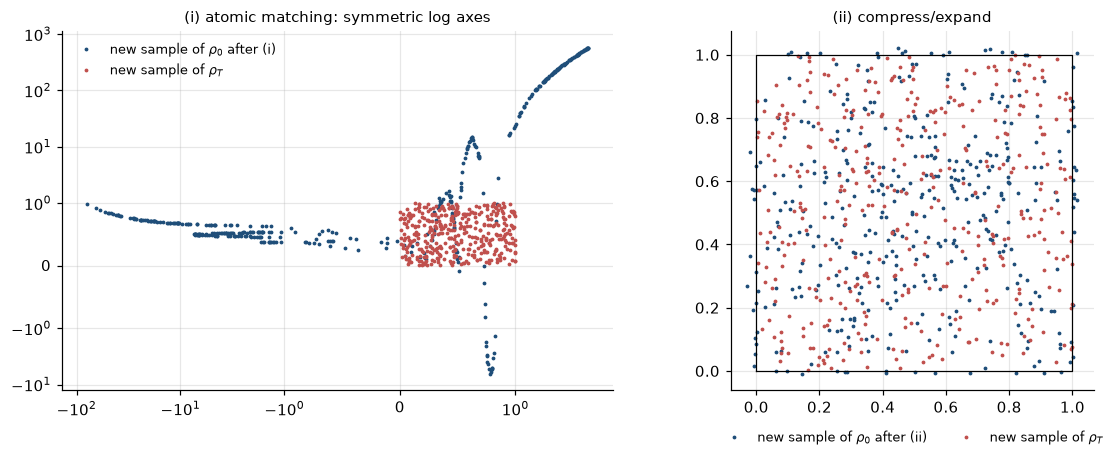

In [4]:
e1, e2 = np.eye(2)
c_exp, c_con = np.log(2.0), 3.0
actions_ii = [(c_exp * e1, e1, -0.5), (-c_exp * e1, -e1, 0.5), (c_exp * e2, e2, -0.5), (-c_exp * e2, -e2, 0.5),   # expansions
              (-c_con * e1, e1, -1.0), (c_con * e1, -e1, 0.0), (-c_con * e2, e2, -1.0), (c_con * e2, -e2, 0.0)]   # contractions


def transport_ii(X):
    for w, a, b in actions_ii:                                    # each action: x' = w max(a.x + b, 0) for unit time, exact
        X = relu_action_exact(X, w, a, b, 1.0)
    return X


# Final evaluation of Laboratory A (protocol section 16): new samples, drawn once, after both transports were fixed.
X0_eval, X1_eval = samples_E8(streams["eval"], n=400)
labA = {"before": {"atoms": W1_atoms_before, "new samples": w1_assignment(X0_eval, X1_eval)[0]},
        "(i) atomic matching": {"atoms": w1_assignment(transport(X0_atoms, layers_i), X1_atoms)[0],
                                "new samples": w1_assignment(transport(X0_eval, layers_i), X1_eval)[0]},
        "(ii) compress/expand": {"atoms": w1_assignment(transport_ii(X0_atoms), X1_atoms)[0],
                                 "new samples": w1_assignment(transport_ii(X0_eval), X1_eval)[0]}}
print("                          W1 atoms (n = 8)    W1 new samples (n = 400)")
for name, r in labA.items():
    print(f"{name:24s}  {r['atoms']:16.2e}    {r['new samples']:22.4f}")
# Reference level (development stream, not evaluation data): W1 between two independent samples of rho_T of size 400.
W1_reference = w1_assignment(samples_E8(streams["dev"], n=400)[1], samples_E8(streams["dev"], n=400)[1])[0]
print(f"reference: W1 between two independent samples of U([0,1]^2), n = 400 each: {W1_reference:.4f}")
sample_i, sample_ii = transport(X0_eval, layers_i), transport_ii(X0_eval)
print(f"after (i), largest |x| of the transported sample {np.abs(sample_i).max():.1e}; after (ii), fraction outside "
      f"[0,1]^2 {np.mean(np.any((sample_ii < 0) | (sample_ii > 1), axis=1)):.3f} (contractions approach the sides, never cross)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.plot(*sample_i.T, ".", ms=3, color=COLORS["state"], label="new sample of $\\rho_0$ after (i)")
ax1.plot(*X1_eval.T, ".", ms=3, color=COLORS["control"], label="new sample of $\\rho_T$")
ax1.set_xscale("symlog", linthresh=1); ax1.set_yscale("symlog", linthresh=1)
ax1.set_title("(i) atomic matching: symmetric log axes", fontsize=10); ax1.legend(fontsize=8.5)
ax2.plot(*sample_ii.T, ".", ms=3, color=COLORS["state"], label="new sample of $\\rho_0$ after (ii)")
ax2.plot(*X1_eval.T, ".", ms=3, color=COLORS["control"], label="new sample of $\\rho_T$")
ax2.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color="black", lw=0.8); ax2.set_aspect("equal")
ax2.set_title("(ii) compress/expand", fontsize=10)
ax2.legend(fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
plt.tight_layout(); plt.show()

**Figure 2.** Laboratory A on the evaluation samples. *Left:* 400 new points of $\rho_0$ after transport (i) (symmetric logarithmic axes) and 400 new points of $\rho_T$. *Right:* the same new points of $\rho_0$ after transport (ii), the new points of $\rho_T$, and the unit square.

*Interpretation (answer to the prediction).* Transport (ii). Transport (i) is exact on the eight atoms, but it sends the new sample of $\rho_0$ far away: $W_1$ grows from $0.20$ to $72$, and transported points reach $|x|\approx580$ (printed). Its speeds were chosen to land eight points, and every other point is moved by the same piecewise-linear displacements, which are enormous between the atoms. Transport (ii) never looks at the atoms: their $W_1$ barely changes. It reduces $W_1$ between the new samples from $0.20$ to $0.061$, because the expansions spread the Gaussian mass over the square and the contractions pull the tails back towards its sides. About $15\%$ of the points stay just outside, since a contraction never crosses its hyperplane. For scale, two independent samples of the uniform law of the same size are already at $W_1\approx0.055$ from each other (printed reference), close to the $0.061$ reached by (ii): $W_1$ between finite samples includes sampling fluctuation. Neither transport is the construction of the theorem. The comparison shows that a transport must be judged on the law, with new samples, and that exact matching of a sample is the transport analogue of interpolating training data.

## 5. Learning a dynamics from trajectories: semi-autonomous neural ODEs
`CORE`

**The model** (p. 375). A *semi-autonomous* neural ODE (SA-NODE) is
$$
x'(t)=\sum_{i=1}^Pw_i\,\sigma\big(a_i^1\cdot x(t)+a_i^2\,t+b_i\big),\qquad w_i\in\mathbb R^d,\ a_i^1\in\mathbb R^d,\ a_i^2\in\mathbb R,\ b_i\in\mathbb R .
$$
The parameters do **not** depend on time; time enters as an extra input. Compared with a neural ODE whose controls change with $t$, this *greatly reduces the complexity of the model* (p. 375). In matrix form, $x'=W\sigma(A_1x+a_2t+b)$ with $W\in\mathbb R^{d\times P}$, $A_1\in\mathbb R^{P\times d}$, $a_2,b\in\mathbb R^P$. *(The slides' theorems, pp. 376–379, print the parameter spaces as $\mathbb R^d\times\mathbb R^{d\times d}\times\mathbb R^d\times\mathbb R^d$, which does not show the width; we use the dimensions above.)*

**What the slides report** (transcribed, not proved here; Li–Liu–Liverani–Zuazua).
- **Approximation of trajectories** (p. 376). If the true field $f(z,t)$ is uniformly Lipschitz in $z$ with respect to $t$, then for every compact $K$ and $\varepsilon>0$ there is $\bar p$ such that for every $P\ge\bar p$ some parameters give $\|z_{z_0}-x_{z_0}\|_{L^\infty(0,T)}\le\varepsilon$ for **all** initial data $z_0\in K$. *Proof: apply the universal approximation property to $f$, then Gronwall estimates.*
- **A rate** (p. 377). If $f\in H^k_{\rm loc}$ with $k>\frac{d+1}2+2$, then $\sup_t\int_K|z_{z_0}(t)-x_{z_0}(t)|^2dz_0\le C_{T,K,f}/P$.
- **Transport** (p. 379). For a probability measure $\rho_0$ supported in a compact $K$ with $\rho_0\in L^2(K)$, $\sup_tW_1(\rho(t),\rho_\Theta(t))\le C_{T,f,\rho_0}/\sqrt P$.

**A self-contained setting in which the first argument works** *(our sufficient hypotheses, not the slides' text)*. Let $f$ be continuous on $\mathbb R^d\times[0,T]$ and globally Lipschitz in $z$, uniformly in $t$. Then every solution exists on $[0,T]$, and the trajectories from $K$ stay in a compact tube $K_T$. Approximate $f$ uniformly on a compact neighbourhood of $K_T$ by a ReLU field (universal approximation), so that the model trajectories also stay there for a small enough error. Gronwall's inequality (§8) then gives the uniform bound. For the **rate**, local Sobolev regularity alone does not even guarantee that trajectories exist up to time $T$: $x'=x^2$ is smooth and its solutions explode in finite time. One must also assume that the trajectories considered exist on $[0,T]$ and remain in a controlled domain, for instance under the global Lipschitz hypothesis. The **transport rate** inherits the hypotheses on the field used for the trajectory rate, together with a probability density in $L^2$ with compact support; it is not a statement for arbitrary fields. The slides do not let us check the precise hypotheses and constants of the two rates, so we treat them as **reported results with incompletely stated hypotheses** and rely on them only qualitatively.

The last two rates are **not interchangeable**. $C/P$ bounds an integrated *squared* trajectory error, so the root-mean-square error is of order $1/\sqrt P$. $C/\sqrt P$ bounds a $W_1$ distance between densities. The slides attribute the square root to the Wasserstein distance (p. 379). Both are existence statements about *some* parameters, not about the parameters our fitting procedure returns (DEEPER LOOK §8).

**Laboratory B.** The system of p. 380 is
$$
z_1'=z_2,\qquad z_2'=-2z_1-3z_2,
$$
which is the harmonic oscillator E1 under the feedback $u=-x_1-3x_2$ (notebook 05); its matrix is built from `harmonic_oscillator()`. The protocol (`reports/protocol_12_16.md`, section 16) fixes everything below before the evaluation data exist.
- **Trajectories:** on $[0,3]$, 31 sampling times, computed exactly by the matrix exponential, from initial conditions uniform on $[-1,1]^2$. 20 trajectories are for training and 10 for validation. **The split is by whole trajectories**, so no trajectory contributes to two sets.
- **Privileged derivative targets.** The fit uses the true field $f(z)$ at the training points. Raw trajectory data would not provide it; it would have to be estimated, for instance by finite differences. We declare this simplification.
- **Training only the outer weights** *(a simplification)*. The inner parameters $(A_1,a_2,b)$ are drawn once, at random, from the stream `features`; a model of width $P$ uses the first $P$ neurons. $W$ is fitted by ridge least squares, minimizing $\frac1M\sum_j|W\Phi_j-f_j|^2+\lambda|W|_F^2$. No gradient is needed, since the inner parameters are not trained.
- **Choice on validation data:** $P\in\{10,20,40,80,160,320\}$ and $\lambda\in\{10^{-8},10^{-6},10^{-4},10^{-2}\}$ are chosen by the mean, over validation trajectories, of the **trajectory error**, the largest distance between the true and the model trajectory over the sampling times (the metric of p. 383). Each model trajectory is a rollout of the fitted SA-NODE from the true initial condition.
- **One final evaluation**, for the chosen model only, on new initial conditions from the reserved stream, in two strata declared in advance: 20 **in the training region** $[-1,1]^2$, and 20 **outside it** (in $[-2,2]^2$ with $\|z_0\|_\infty>1$).

> **Predict.** Will the model that fits the field best on the training points also have the smallest trajectory errors on validation? And how will the errors outside the training region compare?

   P     lambda   training derivative rmse   validation trajectory error: mean, max
  10     1e-08                   8.33e-02     8.09e-02, 2.73e-01
  10     1e-06                   8.33e-02     8.09e-02, 2.73e-01
  10     1e-04                   8.33e-02     8.08e-02, 2.73e-01
  10     1e-02                   1.31e-01     1.22e-01, 3.31e-01
  20     1e-08                   3.95e-02     2.67e-02, 6.72e-02
  20     1e-06                   3.95e-02     2.66e-02, 6.73e-02
  20     1e-04                   4.05e-02     2.57e-02, 7.15e-02
  20     1e-02                   7.93e-02     4.43e-02, 9.35e-02
  40     1e-08                   1.05e-02     7.37e-03, 1.71e-02
  40     1e-06                   1.05e-02     7.43e-03, 1.75e-02
  40     1e-04                   1.28e-02     9.66e-03, 2.43e-02
  40     1e-02                   4.27e-02     2.98e-02, 5.59e-02
  80     1e-08                   3.82e-03     3.82e-03, 1.01e-02
  80     1e-06                   4.45e-03     4.02e-03, 1.23e-02
  80  

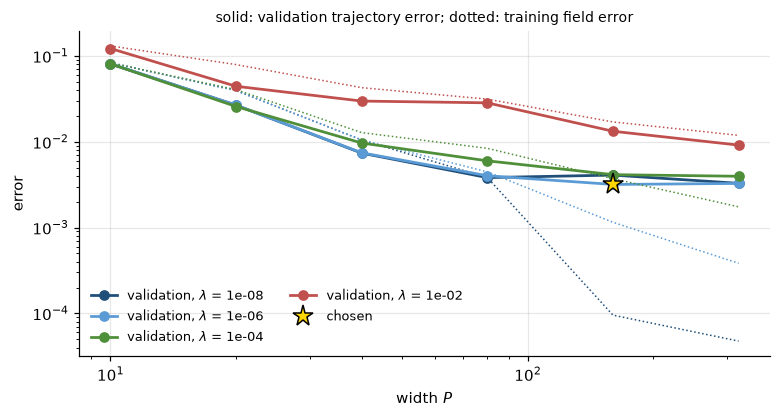

In [5]:
A_osc, B_osc = harmonic_oscillator()
A_cl = A_osc + B_osc @ np.array([[-1.0, -3.0]])                 # z1' = z2, z2' = -2 z1 - 3 z2 (E1 under u = -x1 - 3 x2)
t_grid = np.linspace(0.0, 3.0, 31)
exact_trajectory = lambda z0: np.array([expm(A_cl * t) @ z0 for t in t_grid])
ic_train = streams["data"].uniform(-1, 1, size=(20, 2))
ic_val = streams["data"].uniform(-1, 1, size=(10, 2))
Z_train = np.array([exact_trajectory(z0) for z0 in ic_train])
Z_val = np.array([exact_trajectory(z0) for z0 in ic_val])
P_max = 320
A1_all = streams["features"].normal(size=(P_max, 2))
a2_all = streams["features"].normal(size=P_max)
b_all = streams["features"].uniform(-1, 1, size=P_max)
Z_pts, t_pts = Z_train.reshape(-1, 2), np.tile(t_grid, len(ic_train))
F_pts = Z_pts @ A_cl.T                                           # privileged derivative targets f(z) = A_cl z
widths, lams = [10, 20, 40, 80, 160, 320], [1e-8, 1e-6, 1e-4, 1e-2]


def fit_sa_node(P, lam):
    inner = (A1_all[:P], a2_all[:P], b_all[:P])
    Phi = sa_features(Z_pts, t_pts, *inner)
    W = fit_outer_weights(Phi, F_pts, lam)
    return W, inner, float(np.sqrt(np.mean(np.sum((Phi @ W.T - F_pts) ** 2, axis=1))))


def trajectory_errors(W, inner, ics, Z_true):
    return np.array([trajectory_error(Z, sa_node_rollout(z0, W, *inner, t_grid)) for z0, Z in zip(ics, Z_true)])


table_B, models_B = {}, {}
for P in widths:
    for lam in lams:
        W, inner, der = fit_sa_node(P, lam)
        err = trajectory_errors(W, inner, ic_val, Z_val)
        models_B[(P, lam)] = (W, inner)
        table_B[(P, lam)] = {"training derivative rmse": der, "validation mean": float(err.mean()), "validation max": float(err.max())}
best_B = min(table_B, key=lambda k: (table_B[k]["validation mean"], k[0], -k[1]))
print("   P     lambda   training derivative rmse   validation trajectory error: mean, max")
for (P, lam), r in table_B.items():
    print(f"{P:4d}   {lam:7.0e}   {r['training derivative rmse']:24.2e}   {r['validation mean']:10.2e}, {r['validation max']:.2e}"
          + ("  <- chosen" if (P, lam) == best_B else ""))
best_field = min(table_B, key=lambda k: table_B[k]["training derivative rmse"])
print(f"best training field fit: {best_field}, validation mean {table_B[best_field]['validation mean']:.2e}")

fig, ax = plt.subplots(figsize=(7.2, 3.9))
for lam, col in zip(lams, (COLORS["state"], COLORS["state2"], COLORS["adjoint"], COLORS["control"])):
    ax.loglog(widths, [table_B[(P, lam)]["validation mean"] for P in widths], "o-", color=col, label=f"validation, $\\lambda$ = {lam:.0e}")
    ax.loglog(widths, [table_B[(P, lam)]["training derivative rmse"] for P in widths], ":", color=col, lw=1)
ax.plot(best_B[0], table_B[best_B]["validation mean"], "*", ms=14, color="black", mfc="gold", label="chosen")
ax.set_xlabel("width $P$"); ax.set_ylabel("error"); ax.legend(fontsize=8.5, ncol=2)
ax.set_title("solid: validation trajectory error; dotted: training field error", fontsize=9)
plt.tight_layout(); plt.show()

**Figure 3.** Laboratory B, choice on validation data. For each regularization $\lambda$: the mean validation trajectory error (solid) and the root-mean-square field error on the training points (dotted), against the width $P$. The star marks the model chosen.

*Interpretation (answer to the first part of the prediction).* No. The best field fit on the training points ($P=320$, $\lambda=10^{-8}$, field error $5\cdot10^{-5}$) is not the chosen model. The chosen one ($P=160$, $\lambda=10^{-6}$) has a field error more than twenty times larger, a slightly smaller mean validation trajectory error, and a clearly smaller worst case. From $P=80$ on, the validation error stagnates around $3$–$4\cdot10^{-3}$ while the field error keeps falling: fitting the field ever more precisely at the training points no longer improves trajectories elsewhere. The smallest $\lambda$ gives the largest worst-case errors at large widths, and the largest $\lambda$ underfits at every width.

in the training region      : trajectory error mean 1.67e-03, max 7.54e-03


outside the training region : trajectory error mean 2.14e-02, max 5.53e-02


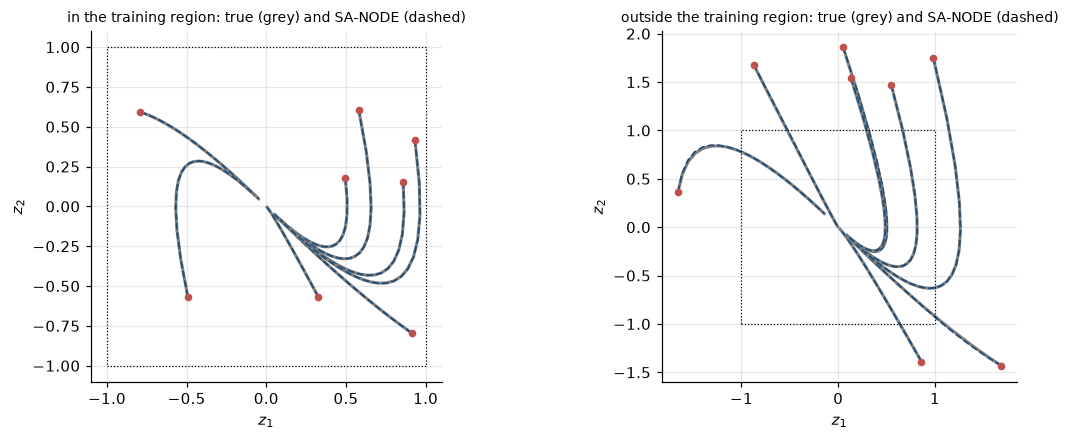

In [6]:
# Final evaluation of Laboratory B (protocol section 16): new initial conditions from the reserved stream, drawn
# once, after the choice above; the chosen model only.
ic_in = streams["eval"].uniform(-1, 1, size=(20, 2))
ic_out = []
while len(ic_out) < 20:
    z0 = streams["eval"].uniform(-2, 2, size=2)
    if np.abs(z0).max() > 1:
        ic_out.append(z0)
ic_out = np.array(ic_out)
W_B, inner_B = models_B[best_B]
final16 = {"chosen (P, lambda)": best_B, "training derivative rmse": table_B[best_B]["training derivative rmse"]}
for name, ics in (("in the training region", ic_in), ("outside the training region", ic_out)):
    Z_true = np.array([exact_trajectory(z0) for z0 in ics])
    err = trajectory_errors(W_B, inner_B, ics, Z_true)
    final16[name] = {"mean": float(err.mean()), "max": float(err.max())}
    print(f"{name:28s}: trajectory error mean {err.mean():.2e}, max {err.max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))
for ax, (name, ics) in zip(axes, (("in the training region", ic_in), ("outside the training region", ic_out))):
    for z0 in ics[:8]:
        Z = exact_trajectory(z0)
        X = sa_node_rollout(z0, W_B, *inner_B, t_grid)
        ax.plot(*Z.T, color=COLORS["reference"], lw=2)
        ax.plot(*X.T, "--", color=COLORS["state"], lw=1.2)
        ax.plot(*z0, "o", color=COLORS["control"], ms=4)
    ax.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], ":", color="black", lw=0.8)
    ax.set_title(f"{name}: true (grey) and SA-NODE (dashed)", fontsize=9); ax.set_aspect("equal")
    ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
plt.tight_layout(); plt.show()

**Figure 4.** Laboratory B, final evaluation: eight of the twenty new trajectories of each stratum, true (grey) and rolled out by the chosen SA-NODE (dashed), with the training region $[-1,1]^2$ dotted.

*Interpretation (answer to the second part of the prediction).* In the training region the final errors (mean $1.7\cdot10^{-3}$, maximum $7.5\cdot10^{-3}$) are of the size seen on validation. Outside it they are about thirteen times larger (mean $2.1\cdot10^{-2}$, maximum $5.5\cdot10^{-2}$). Those trajectories start where there were no training data, and the field error there is not controlled by the fit (DEEPER LOOK §8). They still look qualitatively right because the true dynamics is stable and carries them into the training region, where the model is accurate. Both strata were declared before the data were drawn, and the numbers were computed once, after the choice.

## 6. Control ↔ ML
`CORE`

- **Generative modelling = transport of measures by a controlled flow.** **DIRECT CONNECTION** (pp. 372–374). Normalizing flows push a simple law to a target law; here the "control" is the neural field and the target is reached in $W_1$.
- **Optimal transport → neural transport.** **DIRECT CONNECTION** (p. 372; notebook 06). The optimal assignment chose which atom goes where in transport (i).
- **Learning a dynamics = system identification.** **DIRECT CONNECTION** (pp. 375–383). The SA-NODE is a model of an unknown vector field fitted to trajectories. Its error on new trajectories, not its fit to the field, is what matters, and Gronwall's inequality links the two (DEEPER LOOK §8).
- **Atoms versus laws, fit versus generalization.** **MATHEMATICAL ANALOGY** with notebooks 12 and 14. Driving finitely many atoms exactly is the transport analogue of interpolating training data. It says nothing about the law, just as exact classification of training points said nothing about new points.

## 7. Common misconceptions
`CORE`

**"A flow that maps the sample points exactly onto the target points transports the distribution."** Transport (i) does the first and fails the second by orders of magnitude (Figure 2).

**"Transported atoms change their mass where the flow expands."** Atoms keep their weights; only densities change by the volume factor (§1).

**"$W_1$ between samples can be computed with the squared cost, or by slicing."** The optimal mean squared cost is $W_2^2$, not $W_1$, and sliced distances are yet another quantity. For equal-size samples, $W_1$ is an assignment problem with Euclidean cost (§2).

**"The rates $C/P$ and $C/\sqrt P$ say the same thing."** They bound different quantities (§5).

**"A small error on the field means accurate trajectories everywhere."** The field fit is measured where the data are, and trajectory errors can grow along the flow and outside the training region (Figures 3–4, DEEPER LOOK §8).

## 8. From field errors to trajectory errors: Gronwall
`DEEPER LOOK`

Let $z'=f(z,t)$ be the true dynamics and $x'=f_\Theta(x,t)$ the model, with the same initial value, and suppose $f_\Theta$ is Lipschitz in $x$ with constant $L_\Theta$. Then, with $\delta=\sup_{s\le t}|f(z(s),s)-f_\Theta(z(s),s)|$, the field error **along the true trajectory**,
$$
|z(t)-x(t)|\le\int_0^t|f(z)-f_\Theta(z)|\,ds+\int_0^t|f_\Theta(z)-f_\Theta(x)|\,ds\le\delta t+L_\Theta\!\int_0^t|z-x|\,ds,
$$
and Gronwall's lemma gives $|z(t)-x(t)|\le\delta\,\frac{e^{L_\Theta t}-1}{L_\Theta}$ (and $\le\delta t$ if $L_\Theta=0$). This is the second step of the proofs sketched on pp. 376–377. It explains why a good field fit near the data is not enough. The error is amplified by $e^{L_\Theta T}$, and $\delta$ is the field error *along the trajectory*, which outside the training region is not controlled by the fit. For a ReLU field, $L_\Theta\le\|W\|\,\|A_1\|$ (spectral norms). The cell evaluates the formula for the chosen model on the validation trajectories, **as an estimate on the time grid**. It replaces $\delta$ by the largest field error over the 31 sampling times, which is not the supremum over $[0,T]$, and compares the result with the trajectory error, itself measured only at the sampling times. This shows the size of the formula; it does not verify the continuous inequality. Certifying it would need a bound on the field error between the grid points, for instance from a Lipschitz bound in time of the residual and the grid spacing. A finer grid alone would certify nothing either.

**About the rates.** The theorems guarantee that *some* parameters achieve errors of order $1/\sqrt P$ (root-mean-square) or $C/\sqrt P$ in $W_1$. Our inner parameters are random and not optimized, and $\lambda$ is chosen on validation data, so the curves of Figure 3 are not a test of those rates.

In [7]:
L_theta = np.linalg.norm(W_B, 2) * np.linalg.norm(inner_B[0], 2)
T_end = t_grid[-1]
factor = T_end if L_theta == 0 else np.expm1(L_theta * T_end) / L_theta    # (e^(LT)-1)/L, or T if L = 0 (no overflow here)
rows = []
for z0, Z in zip(ic_val, Z_val):
    Phi_traj = sa_features(Z, t_grid, *inner_B)
    delta_grid = np.linalg.norm(Z @ A_cl.T - Phi_traj @ W_B.T, axis=1).max()  # max over the 31 sampling times only
    observed = trajectory_error(Z, sa_node_rollout(z0, W_B, *inner_B, t_grid))  # also measured at the sampling times
    rows.append((delta_grid, observed, delta_grid * factor))
rows = np.array(rows)
print(f"L_Theta <= {L_theta:.2f};  factor (e^(L T) - 1)/L = {factor:.2e}")
print("grid field error, grid trajectory error, grid estimate of the Gronwall formula (not a certified bound):")
print(rows)

L_Theta <= 17.62;  factor (e^(L T) - 1)/L = 5.07e+21
grid field error, grid trajectory error, grid estimate of the Gronwall formula (not a certified bound):
[[2.7898e-02 3.0040e-03 1.4143e+20]
 [1.4657e-02 2.2472e-03 7.4303e+19]
 [6.1114e-03 7.2318e-04 3.0981e+19]
 [8.2752e-03 1.1952e-03 4.1951e+19]
 [1.1382e-02 1.6115e-03 5.7700e+19]
 [1.3611e-01 3.8676e-03 6.9000e+20]
 [3.2363e-03 3.4956e-04 1.6406e+19]
 [4.4423e-02 2.0417e-03 2.2520e+20]
 [1.3956e-02 1.3864e-03 7.0750e+19]
 [2.7878e-01 1.5358e-02 1.4133e+21]]


*Reading the output.* The grid estimate of the formula exceeds the observed errors by more than twenty orders of magnitude: with $L_\Theta\le\|W\|\|A_1\|\approx18$, the factor $(e^{L_\Theta T}-1)/L_\Theta$ is of order $10^{21}$, while the observed errors are of order $10^{-3}$. Both sides are evaluated on the time grid, so this comparison is an illustration of the size of the formula, not a verification of the inequality. Two reasons explain the gap. The product of norms vastly overestimates the Lipschitz constant that matters along the trajectories. And the true dynamics is **asymptotically stable** (eigenvalues $-1$ and $-2$), which a worst-case estimate ignores. It is not a contraction in the Euclidean norm: the symmetric part of $A_{\rm cl}$ has a positive eigenvalue. Gronwall's inequality explains the *mechanism*: errors are driven by the field error along the trajectory and amplified by the flow. It does not predict their size.

## 9. Numerical results and open directions in the slides
`RESEARCH WINDOW`

- **Pendulum** (p. 381): the same SA-NODE learns $z_1'=z_2$, $z_2'=-\sin z_1$ (Exercise 5).
- **Transport of a density** (p. 382, ongoing work on optimal fluid mixing): the SA-NODE approximates the transport equation of *Doswell frontogenesis*, $\partial_t\rho+\operatorname{div}\big(\rho\,(-yg(r),xg(r))\big)=0$, whose exact solution is known.
- **Comparison with vanilla NODEs** (p. 383). On the linear system of Laboratory B and on a non-autonomous one, the slides report maximum trajectory errors of $4.65\cdot10^{-2}$ to $1.58\cdot10^{-2}$ for SA-NODEs with 1200–12000 degrees of freedom, against $2.6\cdot10^{-1}$ to $9.2\cdot10^{-2}$ for vanilla NODEs with 50000–500000 (autonomous case): *better accuracy with fewer parameters*. These numbers come from a different training procedure (all parameters trained) and are not comparable with ours.
- **Statistical error** (p. 372). *Chebyshev's inequality allows estimating the statistical error of sampling for normalizing flows*. The distance between an empirical sample and its law is itself a random quantity, which is why Laboratory A compares two samples and why its numbers have sampling fluctuation.
- **Perspectives** (p. 384): momentum ResNets, width/depth, dimensionality and probabilities, federated learning, relaxed neural ODEs; and, for digital twins, scalability, reliability and generalization.

## 10. What you should remember
`CORE`

1. A neural ODE transports a measure by push-forward; the trajectories are the characteristics of the transport equation. Atoms keep their masses; densities change by the volume factor.
2. $W_1$ is computed by quantiles in one dimension and, between equal-size samples, by an assignment with Euclidean cost.
3. Finitely many atoms can be driven exactly to finitely many targets (two phases of shears in the plane), but that does not transport the law they were drawn from.
4. The neural transport theorem concerns absolutely continuous, compactly supported laws approximated in $W_1$; its printed switch count cannot be checked as stated.
5. SA-NODEs with time-independent parameters can learn a dynamics; trajectories, not field values, must be split, validated and evaluated, and Gronwall's inequality links field errors to trajectory errors.

## 11. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (mass and volume)** · `FIRST PASS`. One ReLU expansion action $x'=w\sigma(a\cdot x+b)$ with $w=c\,a$, $|a|=1$, $c>0$, acts for a time $t$ on the plane. (a) Show that on the active side it maps $x$ to $x+a\,s(x)(e^{ct}-1)$, $s=a\cdot x+b$, and compute its Jacobian determinant. (b) A density $\rho_0$ is pushed forward: what is the new density at the image of a point of the active side? (c) An atom of mass $0.3$ sits on the active side: what is its mass after the action?

**Exercise 2 ★★ ($W_1$ on the line)** · `FIRST PASS`. Let $\mu=\frac13(\delta_0+\delta_1+\delta_3)$ and $\nu=\frac13(\delta_1+\delta_2+\delta_2)$. (a) Compute $W_1(\mu,\nu)$ from $\int|F_\mu-F_\nu|$ by hand. (b) Check that the sorted-pairs formula gives the same, and compare with `w1_1d`. (c) Show by an example that matching the points in a non-monotone way can cost more.

**Exercise 3 ★★ (Gronwall)** · `STANDARD`. (a) Prove Gronwall's lemma in the form used in §8: if $e(t)\le\delta t+L\int_0^te(s)\,ds$ with $e$ continuous and non-negative, then $e(t)\le\delta(e^{Lt}-1)/L$. (b) Why does the estimate use the field error along the *true* trajectory? Write the alternative estimate with the model trajectory and the Lipschitz constant of $f$. (c) Evaluate the factor $(e^{LT}-1)/L$ for $L=\|A_{\rm cl}\|$ and $T=3$.

**Exercise 4 ★★ (Euclidean or squared cost?)** · `STANDARD`. (a) Find two sets of three points in the plane whose optimal matching for the cost $|x-y|$ differs from the optimal matching for $|x-y|^2$, by a small search over configurations drawn from the stream `dev`. (b) Which of the two would change the value reported in Laboratory A, and why does the theorem of p. 373 use $W_1$?

**Exercise 5 ★★★ (the pendulum)** · `ADVANCED`. Repeat Laboratory B for the pendulum $z_1'=z_2$, $z_2'=-\sin z_1$ of p. 381: exact trajectories are no longer available in closed form, so compute them with `solve_ivp` at tight tolerance. Use the same features, grid and selection rule, and report **validation** errors only (the evaluation stream belongs to Laboratory B's single final evaluation and must not be reused).

In [8]:
# TODO: student exercise (Exercise 5)
# Return the pendulum field (z2, -sin z1) at every row of Z, shape (M, 2).

def pendulum_field(Z):
    ...  # your code here
    return None

**Exercise 6 ★★★ (width and validation error)** · `ADVANCED`. From the table of Laboratory B: (a) plot, for each $P$, the best validation error over $\lambda$, on log–log axes, together with reference lines $\propto P^{-1}$ and $\propto P^{-1/2}$. (b) Which slope do the data resemble, over which range of $P$? (c) Explain why this comparison cannot confirm or refute the rates of pp. 377 and 379.

## Where are we going?
`CORE`

This notebook closes Part IV. Across notebooks 12–16, networks have been read as control systems: shallow networks as linear combinations of features, residual networks as discretized controlled ODEs trained by adjoints, classification as simultaneous control, attention as interacting particles, and generative modelling and system identification as transport and learning of flows. The recurring lesson is the distinction between what a control can *achieve* on given data and what a model *predicts* on new data, which only a protocol fixed in advance can measure. [Notebook 17](17_synthesis_control_and_learning.ipynb) collects the three threads of the course, classifies each control ↔ machine-learning connection by its scope, and lists what remains open.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Push-forward, transport equation | 372 | Neural transport equation; characteristics; $V$ Lipschitz in space |
| §2 $W_1$ | 151, 373 | Monge; $W_1$ in the transport theorem |
| §3 Atoms to atoms | 372, 355 | Atomic data to atomic targets; optimal transport → neural transport; two steps of the simultaneous-control proof |
| §4 Laws are not atoms | 373, 374 | Neural transport theorem (switch formula audited, not reproduced); compress / partition / compress-expand |
| §5 SA-NODEs | 375–380 | SA-NODE; UAP theorem; rate $C/p$; transport rate $C/\sqrt p$; the linear system |
| §6 Control ↔ ML | 372–383 | As above |
| §8 Gronwall (DEEPER LOOK) | 376, 377 | "Apply the UAP to $f$, then Gronwall" |
| §9 Numerical results (RESEARCH WINDOW) | 372, 381–384 | Pendulum; Doswell frontogenesis; comparison with vanilla NODEs; Chebyshev; perspectives |

The source-map rows also record the pedagogical additions:
- the weak identity check and the volume factor;
- the $W_1$ computations;
- the two-phase atomic construction (Figure 1);
- the compress/expand transport and Laboratory A (Figure 2);
- Laboratory B with its protocol (Figures 3–4);
- the Gronwall check.

They also record the corrections:
- the unverifiable switch formula of p. 373;
- the parameter spaces printed on pp. 376–379 without the width;
- E8's Gaussian is not compactly supported;
- $C/P$ and $C/\sqrt P$ bound different quantities.